# In-sample grid: long into the deadline, margin short after the ban (Q5 only)

**The trade.** For every forced short-covering deadline D (Art. 76 last covering day), on the heavily shorted stocks:
**buy the stock at the close of D−k and sell it at the close of D−1** (out before the deadline day), then **open a margin
short at the close of the first day shorting is allowed again** (the day after the ban ends, E+1 — D+4 for 93% of
events) and **cover it h days later**. Everything is doable in an ordinary stock + margin account: no futures.

`climb.ipynb` found the rise in the last ~5 days before D; `drop.ipynb` §4g found a second leg of the fall for 5-day
holds starting around D+8 to D+12, after margin shorting reopens.

**What this notebook does.** It uses only the **first 2/3 of the trading days** (in-sample) to map Sharpe ratio across
every long entry D−k (k = 2…15; the long holds days D−k+1 … D−1) and every short holding length h (1…20 days from the
close of E+1). "no long" is short-only and "no short" is long-only. The last 1/3 is left untouched for an
out-of-sample test of whichever cell is picked here.

**Rules**
* **Q5** = days-to-cover (short balance / 20-day average volume) on **D−17**, at or above the **in-sample 80th
  percentile** of events with any margin shorts. That is one fixed threshold, so it can be applied unchanged
  out-of-sample. The balance is published on the evening of D−17, before any entry used here (latest entry D−15).
* **Liquidity:** 20-day average turnover ≥ NT$20m on D−17.
* **Instrument:** the stock itself, **unhedged**. Long leg: cash stock, **55bp** round trip (30bp sell tax + ~2×4bp
  commission + ~2×8bp slippage). Short leg: margin short (融券), **65bp** round trip (the same plus ~10bp borrow fee
  and recall risk). The short is opened at the **close** of the first allowed day, E+1 (ban end date from
  `suspension.csv`), so the first day it earns is E+2.
* **Sharpe:** a daily P&L series, equal weight across all open positions that day, 0 on days with no position,
  annualised with √252. Costs are charged on the day each leg closes.

## 1. Data and the in-sample split
**What this does.** Loads the TWSE panel and ban calendar (same construction as `climb.ipynb` / `drop.ipynb`), and cuts the
trading calendar at 2/3. An event is in-sample only if its whole widest trade (D−15 to E+1+20) finishes before the cut.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")
K_MAX, H_MAX = 15, 20        # long entry up to D-15; short held up to 20 days from the close of E+1
SIG_LAG = 17
COST_LONG_BPS = 55           # cash stock round trip
COST_SHORT_BPS = 65          # margin short round trip (incl. borrow fee)
MIN_VAL20 = 2e7
Q5_PCT = 0.80

is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])
exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["adj"] = px["adj"].fillna(1.0)
px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["ret"] = px.close / (px.groupby("stock_id")["close_ff"].shift() * px.adj) - 1
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan

idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])
stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, c: df.pivot(index="date", columns="stock_id", values=c).reindex(index=cal, columns=stocks)
R = wide(px, "ret")
SB = wide(mg, "short_bal")
ADV = (wide(px, "volume") / 1000).rolling(20, min_periods=10).mean()
VAL20 = wide(px, "value").rolling(20, min_periods=10).mean()
col = {s: i for i, s in enumerate(stocks)}
T = len(cal)
Rv = R.values

CUT = int(T * 2 / 3)
print(f"{T} trading days {cal[0].date()} -> {cal[-1].date()}")
print(f"in-sample: {cal[0].date()} -> {cal[CUT - 1].date()} ({CUT} days) | held out: {cal[CUT].date()} -> {cal[-1].date()} ({T - CUT} days)")

2122 trading days 2018-01-02 -> 2026-09-23
in-sample: 2018-01-02 -> 2023-10-25 (1414 days) | held out: 2023-10-26 -> 2026-09-23 (708 days)


**What this does.** Builds the deadline events (one per stock per 10 trading days), measures days-to-cover on D−17, sets
the Q5 threshold from in-sample events only, and keeps the liquid in-sample Q5 events.

In [2]:
ev = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
ev = ev[ev.stock_id.isin(stocks)].copy()
ev["D"] = cal.searchsorted(ev.date.values)
ev["E"] = cal.searchsorted(ev.end_date.values, side="right") - 1      # last ban day; margin shorting reopens on E+1
ev = ev[(ev.D >= SIG_LAG + 1) & (ev.E >= ev.D) & (ev.E + H_MAX + 2 < T)]
ev["j"] = ev.stock_id.map(col)
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
s_ = ev.D.values - SIG_LAG
ev["sb"] = SB.values[s_, ev.j.values]
ev["dtc"] = ev.sb / ADV.values[s_, ev.j.values]
ev["val20"] = VAL20.values[s_, ev.j.values]
ev["Ddate"] = cal[ev.D.values]

ins_all = ev[ev.E + H_MAX + 1 < CUT]
has = ins_all[(ins_all.sb > 0) & np.isfinite(ins_all.dtc)]
THR = has.dtc.quantile(Q5_PCT)
ins = has[(has.dtc >= THR) & (has.val20 >= MIN_VAL20)].reset_index(drop=True)
print(f"in-sample events with shorts: {len(has):,}; Q5 threshold (days-to-cover on D-17) = {THR:.3f}")
print(f"liquid in-sample Q5 events traded: {len(ins):,} on {ins.Ddate.nunique()} deadline dates, "
      f"{ins.stock_id.nunique()} stocks, {ins.Ddate.min().date()} -> {ins.Ddate.max().date()}")
print("per year:", ins.groupby(ins.Ddate.dt.year).size().to_dict())
print("short opens at the close of D+x, x =", (ins.E + 1 - ins.D).value_counts().sort_index().to_dict())

in-sample events with shorts: 7,459; Q5 threshold (days-to-cover on D-17) = 0.166
liquid in-sample Q5 events traded: 1,056 on 361 deadline dates, 392 stocks, 2018-03-05 -> 2023-09-12
per year: {2018: 190, 2019: 220, 2020: 163, 2021: 106, 2022: 197, 2023: 180}
short opens at the close of D+x, x = {3: 22, 4: 1034}


## 2. The grid
**What this does.** For every (k, h): each event holds +1 in the stock on days D−k+1 … D−1 (bought at the close of D−k,
sold at the close of D−1), and −1 on days E+2 … E+1+h (margin short opened at the close of E+1, covered h days later).
Each day's strategy return is the average over all positions open that day, with a leg's cost charged on its last
day and 0 when nothing is open. Sharpe = mean/std × √252 of that daily series.

In [3]:
L_OFF = np.arange(-K_MAX + 1, 0)                           # long days, relative to D: -14 .. -1
S_OFF = np.arange(2, H_MAX + 2)                            # short days, relative to E: +2 .. +21
Dv, Ev, Jv = ins.D.values, ins.E.values, ins.j.values
DAYS = np.hstack([Dv[:, None] + L_OFF[None, :], Ev[:, None] + S_OFF[None, :]])
RET = np.nan_to_num(Rv[DAYS, Jv[:, None]])                 # simple daily returns, events x (long days | short days)
IS_L = np.r_[np.ones(len(L_OFF), bool), np.zeros(len(S_OFF), bool)]
OFFC = np.r_[L_OFF, S_OFF]

def run(k, h, cl=COST_LONG_BPS / 1e4, cs=COST_SHORT_BPS / 1e4):
    # daily P&L series (length T) and per-trade net returns; k = 0 means no long, h = 0 means no short
    use = (IS_L & (OFFC >= -k + 1) & (k >= 2)) | (~IS_L & (OFFC <= h + 1) & (h >= 1))
    if not use.any():
        return None, None
    pnl = np.where(use, np.where(IS_L, 1.0, -1.0), 0.0)[None, :] * RET
    if k >= 2:
        pnl[:, IS_L & (OFFC == -1)] -= cl
    if h >= 1:
        pnl[:, ~IS_L & (OFFC == h + 1)] -= cs
    open_ = np.broadcast_to(use, pnl.shape)
    psum = np.zeros(T); pcnt = np.zeros(T)
    np.add.at(psum, DAYS[open_], pnl[open_])
    np.add.at(pcnt, DAYS[open_], 1)
    daily = np.divide(psum, pcnt, out=np.zeros(T), where=pcnt > 0)[:CUT]
    return daily, pnl.sum(1)

KS, HS = np.r_[0, np.arange(2, K_MAX + 1)], np.arange(0, H_MAX + 1)
SH = pd.DataFrame(np.nan, index=pd.Index(KS, name="k: long from D−k to D−1"), columns=pd.Index(HS, name="h: short days from E+1"))
MU, HIT, TSTAT = SH.copy(), SH.copy(), SH.copy()
for k in KS:
    for h in HS:
        daily, trades = run(k, h)
        if daily is None:
            continue
        SH.loc[k, h] = daily.mean() / daily.std() * np.sqrt(252)
        MU.loc[k, h] = trades.mean() * 1e4
        HIT.loc[k, h] = (trades > 0).mean()
        per_date = pd.Series(trades).groupby(ins.Ddate.values).mean()
        TSTAT.loc[k, h] = per_date.mean() / per_date.std() * np.sqrt(len(per_date))
best = SH.stack().idxmax()
print(f"{SH.notna().sum().sum()} cells; best Sharpe {SH.max().max():.2f} at k={best[0]}, h={best[1]}")

314 cells; best Sharpe 1.06 at k=12, h=0


## 3. Sharpe heatmap
**What this does.** Rows are the long entry (buy at the close of D−k, sell at the close of D−1); columns are how many days
the margin short is held after opening at the close of E+1 (≈ D+4). Each box shows the annualised Sharpe, net of 55bp
(long) and 65bp (short). The top-left box is no trade. The "no long" row is short-only; the "no short" column is long-only.

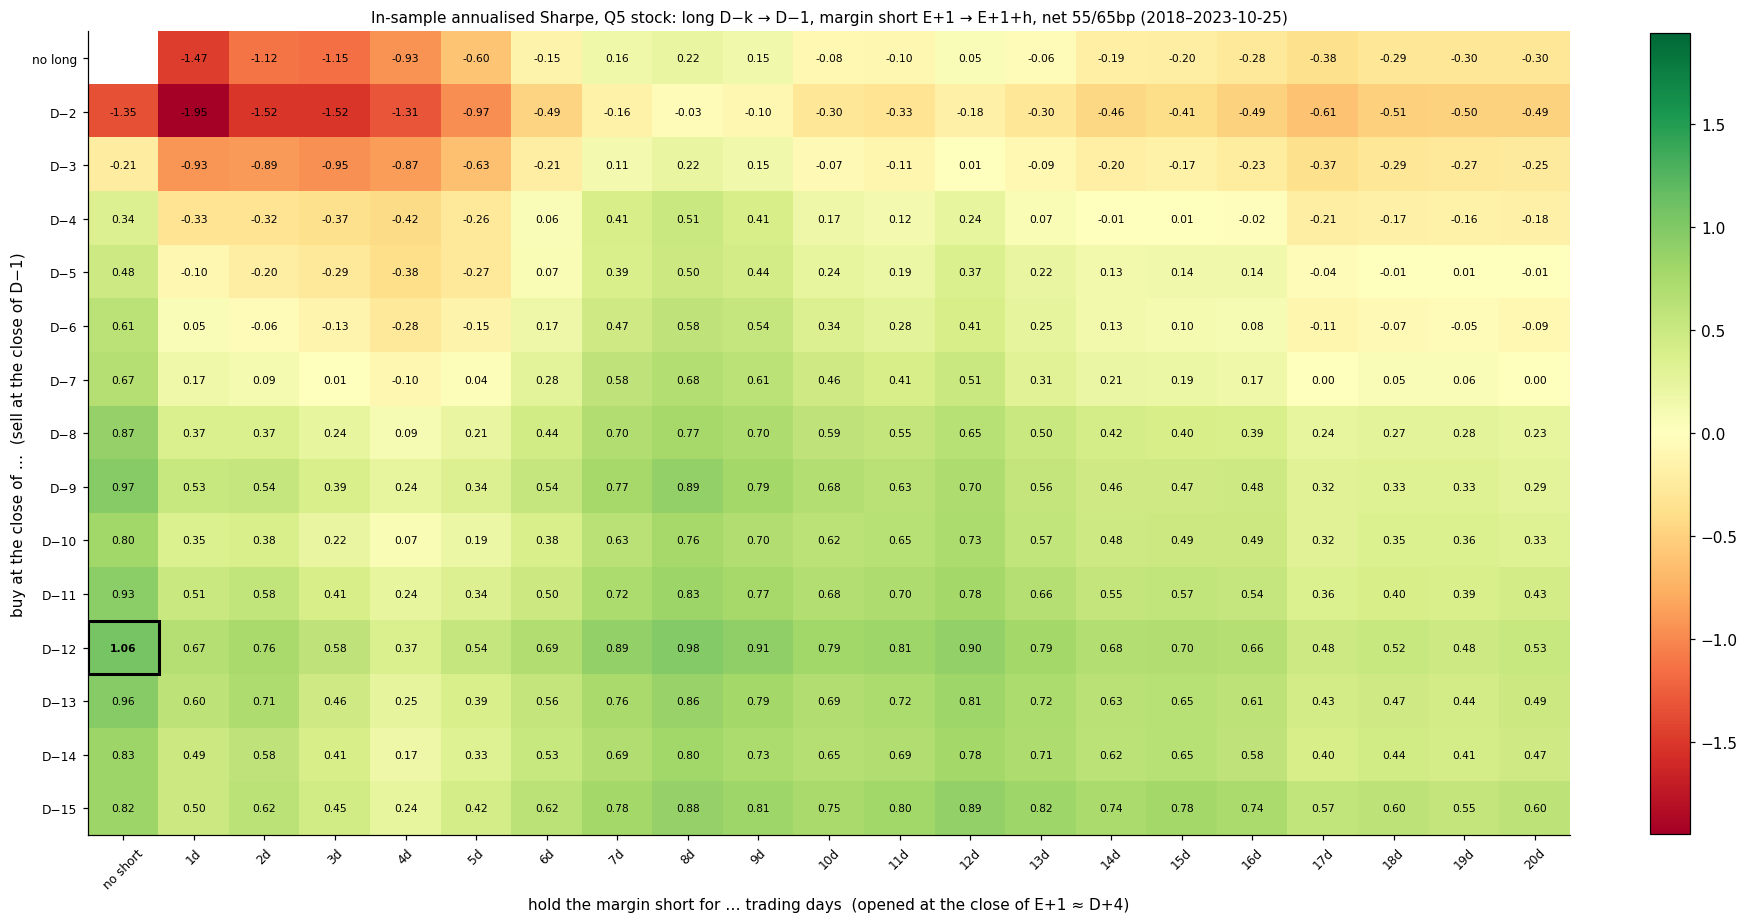

In [4]:
fig, ax = plt.subplots(figsize=(16, 8.5))
v = np.nanmax(np.abs(SH.values))
im = ax.imshow(SH.values, cmap="RdYlGn", vmin=-v, vmax=v, aspect="auto")
ax.set_xticks(range(len(HS)), [f"{h}d" if h else "no short" for h in HS], rotation=45, fontsize=8)
ax.set_yticks(range(len(KS)), [f"D−{k}" if k else "no long" for k in KS], fontsize=8)
ax.set_xlabel("hold the margin short for … trading days  (opened at the close of E+1 ≈ D+4)")
ax.set_ylabel("buy at the close of …  (sell at the close of D−1)")
best = SH.stack().idxmax()
for (i, j), val in np.ndenumerate(SH.values):
    if np.isfinite(val):
        bold = (KS[i], HS[j]) == best
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, fontweight="bold" if bold else "normal",
                color="k")
ax.add_patch(plt.Rectangle((list(HS).index(best[1]) - .5, list(KS).index(best[0]) - .5), 1, 1, fill=False, lw=2, ec="k"))
ax.set_title(f"In-sample annualised Sharpe, Q5 stock: long D−k → D−1, margin short E+1 → E+1+h, net {COST_LONG_BPS}/{COST_SHORT_BPS}bp "
             f"({cal[0].year}–{cal[CUT - 1].date()})", fontsize=10)
plt.colorbar(im, ax=ax, fraction=.025)
plt.tight_layout(); plt.show()

**What this does.** Supporting grids for the same cells: mean net return per round trip (bp) and the per-deadline-date
t-stat. A high Sharpe with only a few bp per trade would not survive a slightly higher cost.

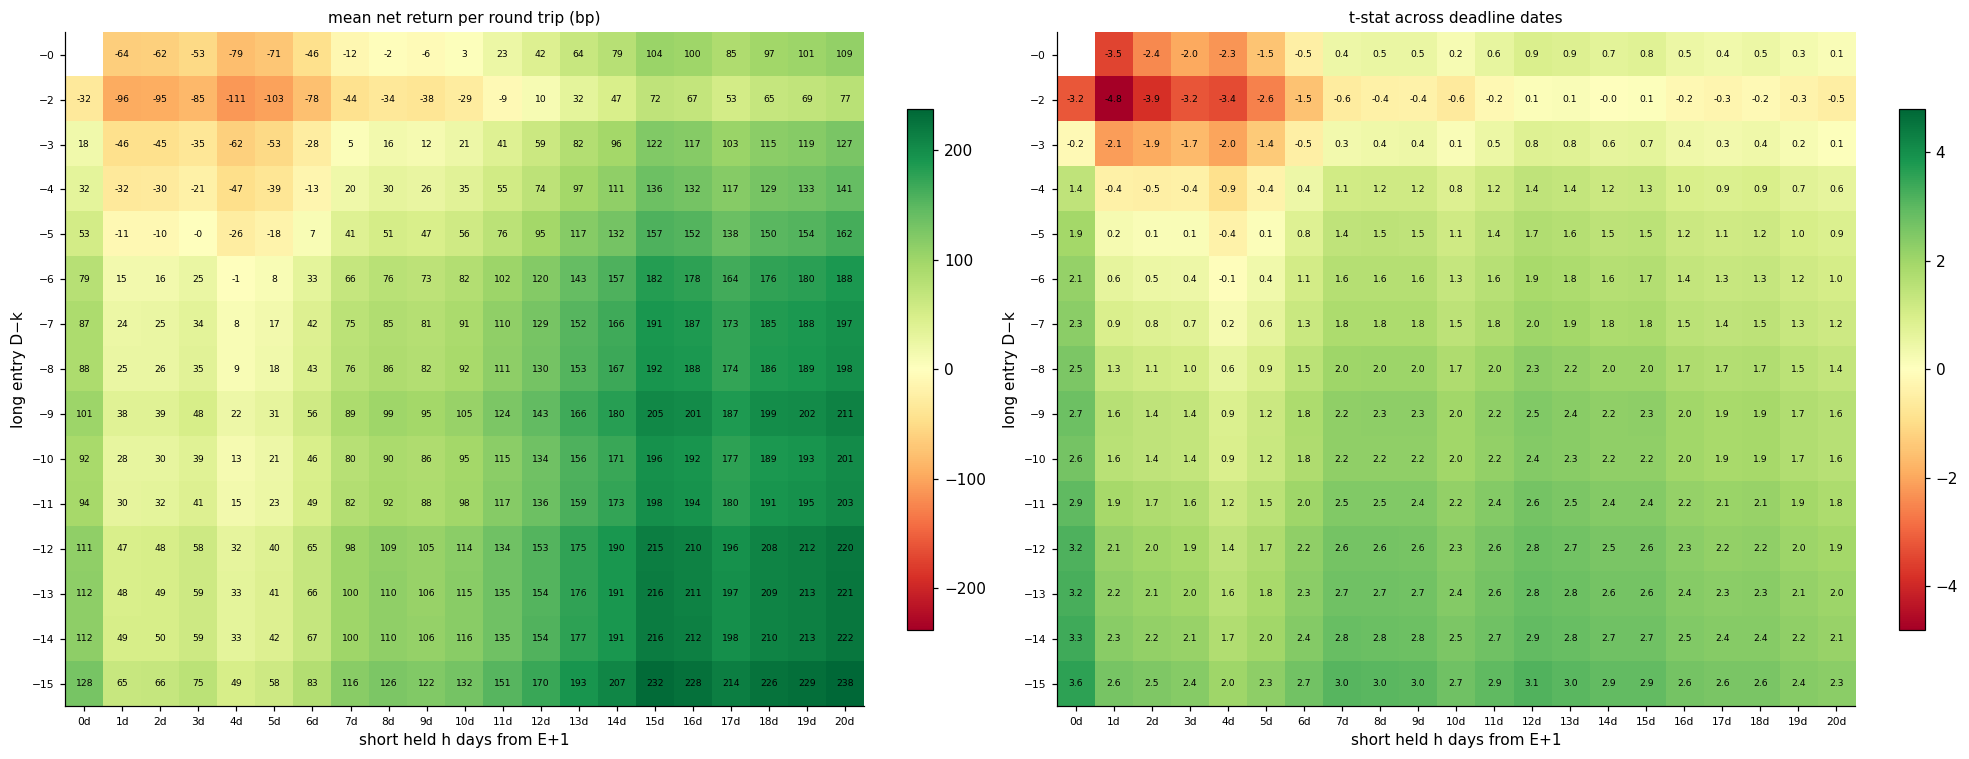

top 10 cells:
                                                sharpe  mean_bp     t   hit
k: long from D−k to D−1 h: short days from E+1                             
12                      0                         1.06   110.74  3.16  0.54
                        8                         0.98   108.65  2.63  0.55
9                       0                         0.97   101.38  2.74  0.55
13                      0                         0.96   111.78  3.23  0.54
11                      0                         0.93    94.11  2.95  0.55
12                      9                         0.91   104.73  2.60  0.56
                        12                        0.90   152.58  2.77  0.58
15                      12                        0.89   170.19  3.11  0.59
12                      7                         0.89    98.47  2.63  0.55
9                       8                         0.89    99.29  2.26  0.57

long-only column (h=0):
k: long from D−k to D−1     2      3      4      

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for a, (M, ttl, fmt) in zip(axes, [(MU, "mean net return per round trip (bp)", "{:.0f}"), (TSTAT, "t-stat across deadline dates", "{:.1f}")]):
    vv = np.nanmax(np.abs(M.values))
    im = a.imshow(M.values, cmap="RdYlGn", vmin=-vv, vmax=vv, aspect="auto")
    a.set_xticks(range(len(HS)), [f"{h}d" for h in HS], fontsize=7); a.set_yticks(range(len(KS)), [f"−{k}" for k in KS], fontsize=7)
    a.set_xlabel("short held h days from E+1"); a.set_ylabel("long entry D−k")
    for (i, j), val in np.ndenumerate(M.values):
        if np.isfinite(val): a.text(j, i, fmt.format(val), ha="center", va="center", fontsize=6)
    a.set_title(ttl, fontsize=10); plt.colorbar(im, ax=a, fraction=.03)
plt.tight_layout(); plt.show()

top = SH.stack().sort_values(ascending=False).head(10).rename("sharpe").to_frame()
top["mean_bp"] = [MU.loc[i] for i in top.index]; top["t"] = [TSTAT.loc[i] for i in top.index]; top["hit"] = [HIT.loc[i] for i in top.index]
print("top 10 cells:"); print(top.round(2).to_string())
print("\nlong-only column (h=0):"); print(pd.DataFrame({"sharpe": SH[0], "mean_bp": MU[0]}).drop(0).round(2).T.to_string())
print("\nshort-only row (k=0):"); print(pd.DataFrame({"sharpe": SH.loc[0], "mean_bp": MU.loc[0]}).drop(0).round(2).T.to_string())

**Interpretation.**
- **Best cell: long only, buy at D−12, sell at D−1.** Sharpe **1.06**, +111bp net per trade (after 55bp), t = 3.2
  across 361 deadline dates, 54% of trades profitable. It sits on a plateau: long-only entries from D−8 to D−15 all
  score 0.8–1.0. Entries at D−2 or D−3 are too short to pay the 55bp stock cost.
- **The post-ban margin short adds nothing in-sample.** Short-only (opened at the close of E+1 ≈ D+4) never beats a
  Sharpe of 0.22, and its best cell (held 8 days) nets −2bp per trade. Holds of 1–5 days lose 53–79bp net: the gross
  drop over those days (drop.ipynb §4g, raw: about −20 to −35bp) is smaller than the 65bp cost. Longer holds (15–20
  days) average +100bp per trade but are noisy (t ≤ 0.9) and have a negative Sharpe on the daily series, so they are
  not a reliable edge.
- **The least-bad short length is 7–9 days**, which lines up with drop.ipynb §4g's second leg (5-day holds starting
  D+8 to D+12). Adding it to the D−12 long gives Sharpe 0.89–0.98 (e.g. D−12 + 8 days: 0.98, +109bp) — slightly
  *below* long-only. The short fights the market's upward drift over 2018–23 and pays 65bp for a small edge.
- **So the D+1 drop, the big one, is exactly the part a stock account cannot reach.** By the time margin shorting
  reopens, most of the fall has happened. The tradeable version of this pitch for a stock-only account is the long leg.
- **Caveats.** The long is unhedged, so part of it is market beta and the seasonal pre-book-closure drift that lightly
  shorted stocks share (climb.ipynb). 314 cells were tried, so the best Sharpe is optimistic; pick from the middle of
  the plateau (buy at D−9 to D−12, sell at D−1) for the out-of-sample test, with the same Q5 threshold (0.166). Sharpe
  and mean per trade can disagree in sign: the Sharpe uses a calendar-time daily series that equal-weights all open
  positions each day, while the mean weights every trade equally.

## 4. Short with single-stock futures instead
**The trade.** Same long leg (buy the **stock** at the close of D−k, sell at the close of D−1, 55bp), but the short leg is
a **single-stock future** (個股期貨), which is not covered by the margin-short ban. So the short can start right after the
deadline: **sell the future at the close of D** (first day earned: D+1), or at the **close of D+1** (first day earned:
D+2), and buy it back h days later. Cost: **20bp** round trip (≈0.4bp futures tax + commission + a tick of spread).

**Futures returns are real TAIFEX prices**, not the stock as a proxy: front month = the contract with the most open
interest, held from one day to the next and rolled when open interest moves. Price = daily settlement (close if no
settlement). On ex-dividend days the prior price is scaled by the same factor as the stock (TAIFEX adjusts the
contract, so the futures price drops with the dividend but the position value does not). Days with no futures price
earn 0.

**Only stocks with a listed future** can be traded this way: this is a subset of the Q5 events (mostly larger names), so
its long-only column is not the same as section 3's.

In [6]:
f = pd.read_csv(DATA / "stock_futures.csv", dtype={"contract_date": str}, parse_dates=["date"])
f = f[f.contract_date.str.len() == 6].copy()                      # single months only (drop calendar spreads)
f["px"] = np.where(f.settlement_price > 0, f.settlement_price, np.where(f.close > 0, f.close, np.nan))
fm = pd.read_csv(DATA / "futures_map.csv", dtype={"stock_id": str}); fm["futures_id"] = fm.prefix + "F"
f = f.merge(fm[["futures_id", "stock_id"]], on="futures_id")
main_id = f.groupby(["stock_id", "futures_id"]).volume.sum().reset_index().sort_values("volume").drop_duplicates("stock_id", keep="last")
f = f[f.futures_id.isin(main_id.futures_id)]                      # one contract per stock (regular, not mini)
front = f.loc[f.groupby(["stock_id", "date"]).open_interest.idxmax(), ["stock_id", "date", "contract_date"]].sort_values(["stock_id", "date"])
front["held"] = front.groupby("stock_id").contract_date.shift()    # the contract you carried into today
front["prev"] = front.groupby("stock_id").date.shift()
pser = f.set_index(["stock_id", "date", "contract_date"]).px
front["p1"] = pser.reindex(pd.MultiIndex.from_arrays([front.stock_id, front.date, front.held])).values
front["p0"] = pser.reindex(pd.MultiIndex.from_arrays([front.stock_id, front.prev, front.held])).values
front = front.merge(px[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
front["fret"] = front.p1 / (front.p0 * front.adj.fillna(1.0)) - 1
front.loc[front.fret.abs() > 0.11, "fret"] = np.nan
FR = front[front.stock_id.isin(stocks)].pivot(index="date", columns="stock_id", values="fret").reindex(index=cal, columns=stocks).values
chk = pd.DataFrame({"f": FR.ravel(), "s": Rv.ravel()}).dropna()
print(f"futures on {front.stock_id.nunique()} stocks; daily futures vs stock return: corr {chk.f.corr(chk.s):.3f}, "
      f"median |diff| {(chk.f - chk.s).abs().median() * 1e4:.0f}bp")

has_fut = np.isin(ins.stock_id.values, front.stock_id.unique())
insF = ins[has_fut].reset_index(drop=True)
print(f"in-sample Q5 events with a listed future: {len(insF):,} of {len(ins):,} ({has_fut.mean():.0%}) on "
      f"{insF.Ddate.nunique()} deadline dates, {insF.stock_id.nunique()} stocks")

COST_FUT_BPS = 20
DvF, JvF = insF.D.values, insF.j.values
L_DAYS = DvF[:, None] + L_OFF[None, :]
RL = np.nan_to_num(Rv[L_DAYS, JvF[:, None]])                    # long leg: stock
S_REL = np.arange(1, H_MAX + 2)                                 # D+1 .. D+21
S_DAYS = DvF[:, None] + S_REL[None, :]
RS_FUT = FR[S_DAYS, JvF[:, None]]
print(f"futures price available on {np.isfinite(RS_FUT[:, :10]).mean():.0%} of short-leg days (D+1..D+10)")
RS_FUT = np.nan_to_num(RS_FUT)
RS_STK = np.nan_to_num(Rv[S_DAYS, JvF[:, None]])                # same days, stock returns (for comparison)

def run_f(k, h, s0, RS, cl=COST_LONG_BPS / 1e4, cs=COST_FUT_BPS / 1e4):
    # long stock D-k -> D-1; short future from the close of D+s0 for h days (days D+s0+1 .. D+s0+h)
    useL = (L_OFF >= -k + 1) & (k >= 2)
    useS = (S_REL >= s0 + 1) & (S_REL <= s0 + h) & (h >= 1)
    if not (useL.any() or useS.any()):
        return None, None
    pl = RL * useL; ps = -RS * useS
    if k >= 2: pl[:, L_OFF == -1] -= cl
    if h >= 1: ps[:, S_REL == s0 + h] -= cs
    pnl = np.hstack([pl, ps]); days = np.hstack([L_DAYS, S_DAYS]); use = np.r_[useL, useS]
    open_ = np.broadcast_to(use, pnl.shape)
    psum = np.zeros(T); pcnt = np.zeros(T)
    np.add.at(psum, days[open_], pnl[open_]); np.add.at(pcnt, days[open_], 1)
    daily = np.divide(psum, pcnt, out=np.zeros(T), where=pcnt > 0)[:CUT]
    return daily, pnl.sum(1)

GRID = {}
for s0 in (0, 1):
    sh, mu, ts = (pd.DataFrame(np.nan, index=pd.Index(KS, name="k"), columns=pd.Index(HS, name="h")) for _ in range(3))
    for k in KS:
        for h in HS:
            daily, trades = run_f(k, h, s0, RS_FUT)
            if daily is None: continue
            sh.loc[k, h] = daily.mean() / daily.std() * np.sqrt(252); mu.loc[k, h] = trades.mean() * 1e4
            pdm = pd.Series(trades).groupby(insF.Ddate.values).mean(); ts.loc[k, h] = pdm.mean() / pdm.std() * np.sqrt(len(pdm))
    GRID[s0] = (sh, mu, ts)
    b_ = sh.stack().idxmax()
    print(f"short from the close of D+{s0}: best Sharpe {sh.max().max():.2f} at buy D−{b_[0]}, short {b_[1]} days "
          f"({mu.loc[b_]:.0f}bp/trade, t = {ts.loc[b_]:.1f}); long-only best {sh[0].max():.2f} at D−{sh[0].idxmax()}")

futures on 270 stocks; daily futures vs stock return: corr 0.971, median |diff| 32bp
in-sample Q5 events with a listed future: 422 of 1,056 (40%) on 213 deadline dates, 120 stocks
futures price available on 72% of short-leg days (D+1..D+10)


short from the close of D+0: best Sharpe 0.92 at buy D−14, short 0 days (112bp/trade, t = 1.7); long-only best 0.92 at D−14


short from the close of D+1: best Sharpe 0.92 at buy D−14, short 0 days (112bp/trade, t = 1.7); long-only best 0.92 at D−14


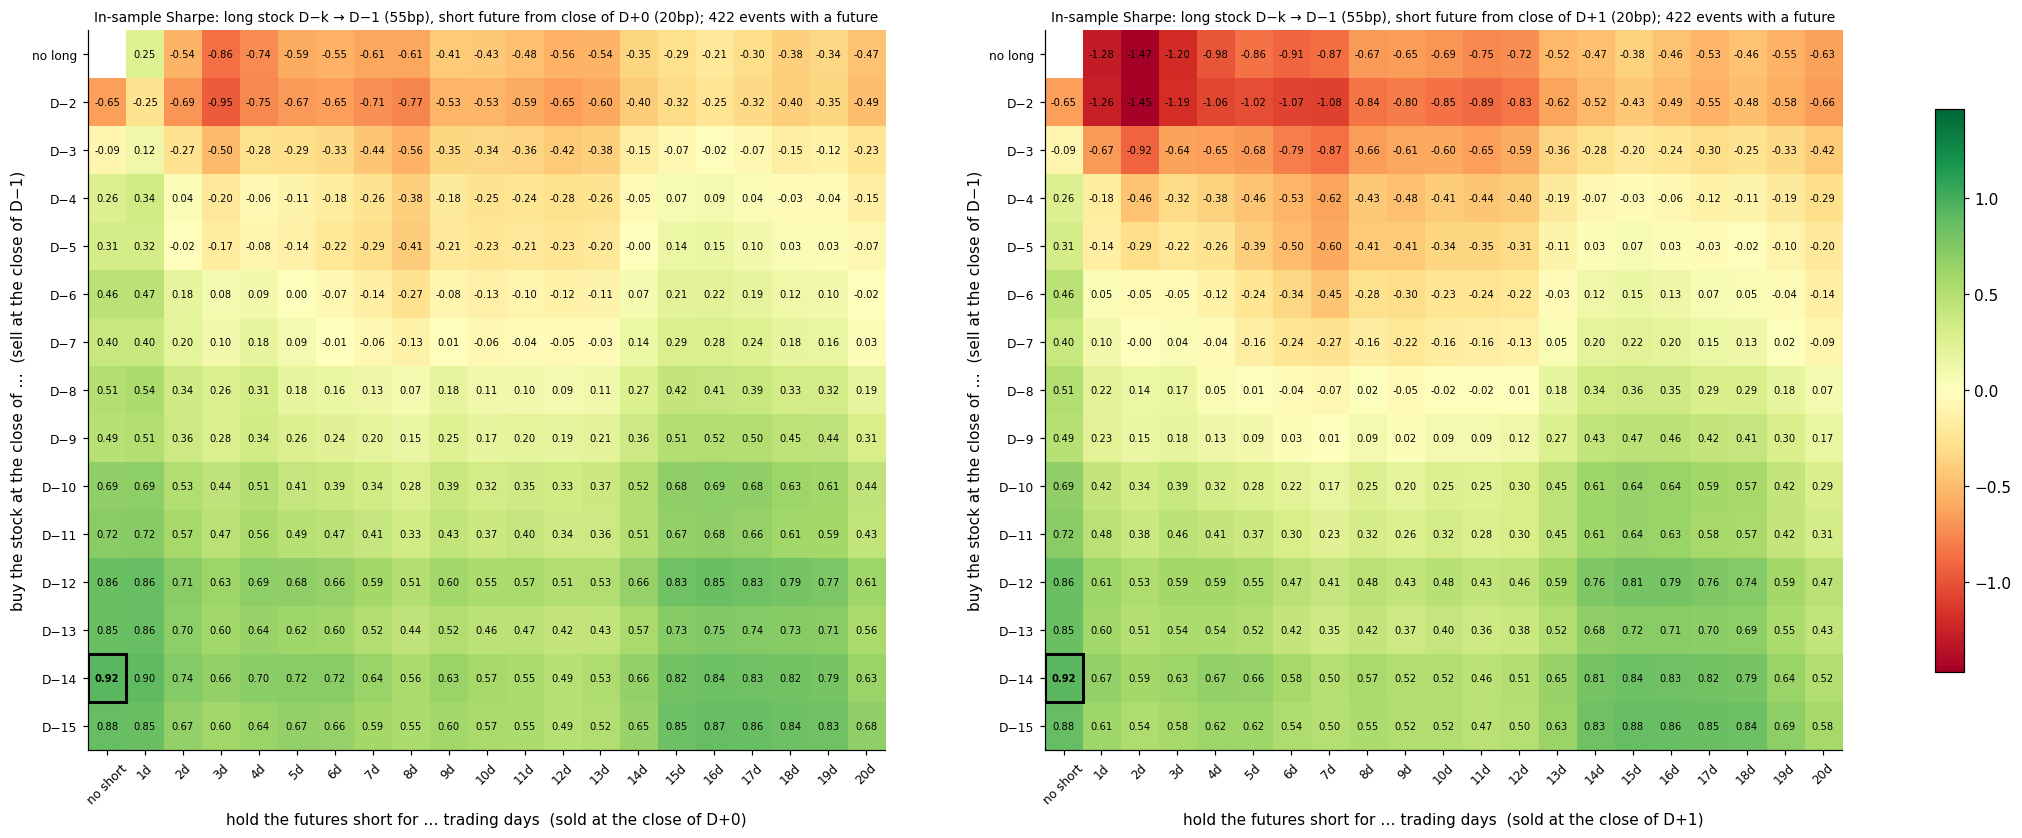


==== short from the close of D+0: top cells
       sharpe  mean_bp     t
k  h                        
14 0     0.92   112.21  1.72
   1     0.90   112.59  1.80
15 0     0.88   124.65  2.11
   16    0.87    95.43  1.40
13 1     0.86   118.94  2.01
12 1     0.86   128.10  2.10
15 17    0.86   108.42  1.42
12 0     0.86   127.72  1.97
short-only row (no long):
h          1      2      3      4      5      6      7       8       9       10     11     12     13     14     15     16     17     18     19    20
sharpe   0.25  -0.54  -0.86  -0.74  -0.59  -0.55  -0.61   -0.61   -0.41   -0.43  -0.48  -0.56  -0.54  -0.35  -0.29  -0.21  -0.30  -0.38  -0.34 -0.47
mean_bp  0.38 -32.90 -56.58 -51.66 -73.56 -76.39 -87.24 -108.46 -118.03 -101.75 -77.47 -69.87 -73.82 -62.84 -41.80 -29.22 -16.23 -10.78  13.90  6.04
t        0.59  -0.92  -1.47  -1.18  -1.40  -1.38  -1.70   -2.05   -1.82   -1.27  -1.32  -1.11  -0.88  -0.79  -0.29  -0.18  -0.12   0.08   0.24 -0.18

==== short from the close of D+1: top cell

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8.5))
v = max(np.nanmax(np.abs(GRID[s0][0].values)) for s0 in GRID)
for a, s0 in zip(axes, (0, 1)):
    sh = GRID[s0][0]
    im = a.imshow(sh.values, cmap="RdYlGn", vmin=-v, vmax=v, aspect="auto")
    a.set_xticks(range(len(HS)), [f"{h}d" if h else "no short" for h in HS], rotation=45, fontsize=8)
    a.set_yticks(range(len(KS)), [f"D−{k}" if k else "no long" for k in KS], fontsize=8)
    a.set_xlabel(f"hold the futures short for … trading days  (sold at the close of D+{s0})")
    a.set_ylabel("buy the stock at the close of …  (sell at the close of D−1)")
    b_ = sh.stack().idxmax()
    for (i, j), val in np.ndenumerate(sh.values):
        if np.isfinite(val):
            a.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6.5, fontweight="bold" if (KS[i], HS[j]) == b_ else "normal")
    a.add_patch(plt.Rectangle((list(HS).index(b_[1]) - .5, list(KS).index(b_[0]) - .5), 1, 1, fill=False, lw=2, ec="k"))
    a.set_title(f"In-sample Sharpe: long stock D−k → D−1 ({COST_LONG_BPS}bp), short future from close of D+{s0} ({COST_FUT_BPS}bp); "
                f"{len(insF)} events with a future", fontsize=9)
plt.colorbar(im, ax=axes, fraction=.015)
plt.show()

for s0 in (0, 1):
    sh, mu, ts = GRID[s0]
    top = sh.stack().sort_values(ascending=False).head(8).rename("sharpe").to_frame()
    top["mean_bp"] = [mu.loc[i] for i in top.index]; top["t"] = [ts.loc[i] for i in top.index]
    print(f"\n==== short from the close of D+{s0}: top cells"); print(top.round(2).to_string())
    print("short-only row (no long):"); print(pd.DataFrame({"sharpe": sh.loc[0], "mean_bp": mu.loc[0], "t": ts.loc[0]}).drop(0).round(2).T.to_string())

# how much do real futures differ from using the stock as a proxy? short-only from the close of D
cmp = {}
for nm, RS in [("futures", RS_FUT), ("stock proxy", RS_STK)]:
    cmp[nm] = [run_f(0, h, 0, RS)[1].mean() * 1e4 for h in (1, 3, 5, 10, 15)]
print("\nshort-only from the close of D, mean net bp/trade, real futures vs stock-return proxy:")
print(pd.DataFrame(cmp, index=pd.Index([1, 3, 5, 10, 15], name="h")).round(1).T.to_string())

**Interpretation.**
- **The futures short does not help either.** With real TAIFEX prices, the best cell with either entry is still
  **long-only** (buy the stock at D−14, sell at D−1: Sharpe 0.92, +112bp/trade, t = 1.7 on the 422 events that have a
  future). Adding a 1-day futures short from the close of D leaves it unchanged (0.90); every longer short lowers it.
- **Short-only from the close of D earns ≈ 0 for one day (+0.4bp net) and then loses** (−57bp at 3 days, −74bp at 5,
  −102bp at 10). From the close of D+1 it loses from the start (−53bp at 1 day, t = −3.1). So on this subset, in-sample,
  the D+1 drop is not there to be captured in raw (unhedged) terms after costs.
- **Two reasons it looks worse than `drop.ipynb`.** (i) This is raw, unhedged P&L over 2018–23, when the market rose;
  `drop.ipynb`'s big numbers are *relative to the market*. Even with the stock as a proxy, the same short earns only
  +25bp at 1 day and is negative by 3 days. (ii) **Real futures capture 25–40bp less than the stock proxy** at every
  horizon (e.g. 1 day: +0.4 vs +25bp; 5 days: −74 vs −35bp). Futures prices are missing on ~28% of the short-leg days
  (thin contracts; those days earn 0), and the futures basis need not move one-for-one with the stock's closing price.
- **Coverage is also limited:** only 40% of the liquid in-sample Q5 events (422 of 1,056; 120 stocks) have a listed future.
- **Bottom line:** in-sample, neither a margin short from D+4 nor a futures short from D or D+1 improves on simply
  buying Q5 at D−9 to D−14 and selling at D−1. If a short is used at all, it is as a hedge (it lowers market exposure),
  not as a source of return. A market-hedged version (short the long's beta in index futures) would be the next test.